The purpose of this notebook is to compare the firn smoothing kernel with a firn smoothing kernel that is half as wide to see how much this would affect the results.

In [1]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import xarray as xr
import numpy as np
from pathlib import Path
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs
from methane_noise_forcing.noise import solve_ch4_anomaly_lifetime
from methane_noise_forcing.naming import (
    generate_noise_realization_name,
    generate_firn_smoothing_name,
    generate_sample_name,
)
from methane_noise_forcing.core import (
    FirnFilter,
    sample_ensemble_series,
    sample_series_at_core_points,
)
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
    large_font,
)
import string
from copy import copy

plt.rcParams.update(matplotlib_rcparams)

In [2]:
## figure settings
fig_width = fig_width_options["two_column_large"]  # inches
ax_height = 1.5  # inches
plot_kwargs = {
    "obs": {
        "color": "k",
        "marker": "o",
        "linestyle": "None",
        "markersize": 2.5,
    },
    "instantaneous": {"color": colors_vibrant["blue"], "linestyle": "-", "alpha": 0.5},
    "smoothed": {
        "color": colors_vibrant["grey"],
        "linestyle": "-",
        "linewidth": 5.5,
        "alpha": 0.8,
    },
    "sampled": {
        "marker": "o",
        "linestyle": "None",
        "markersize": 4,
        "markeredgecolor": "k",
        "markeredgewidth": 1,  # adjust thickness
        "alpha": 1,
        "color": colors_vibrant["orange"],
    },
}

color_smoothed_orig = colors_vibrant["magenta"]
color_smoothed_new = colors_vibrant["grey"]

In [3]:
with initialize(version_base=None, config_path="../../../configs"):
    cfg = compose(config_name="config")

# loading/generating individual components

## load observational data

In [4]:
## parameters
site_name = "wdc06a"  # wdc05a, wdc06a, gisp2, neem
time_min = 800
time_max = 1800

In [5]:
## import data
data_obs = io.load_observational_data(site_name, **cfg.io[site_name].input)
# detrend data
data_obs_detrended = detrend_obs(site_name, data_obs)

# convert to dataset with 'ch4' and 'ch4_detrended'
data_obs = xr.Dataset(
    {
        "ch4": (["time"], data_obs.ch4),
        "ch4_detrended": (["time"], data_obs_detrended.ch4),
    },
    coords={"time": data_obs.gas_age},
)

# invert time axis
data_obs = data_obs.isel(time=slice(None, None, -1))

2026-03-22 15:47:18,015 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2026-03-22 15:47:18,023 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2


## load instantaneous, smoothed, and sampled data from different timescales

In [6]:
timescales = [0.1, 1, 10, 100, 1000]

if (site_name == "wdc05a") or (site_name == "wdc06a"):
    filter_name = "wais"
else:
    filter_name = site_name

instantaneous_noise = {}
smoothed_noise = {}
sampled_noise = {}
for timescale in timescales:
    # resolve paths
    timescale_cfg = timescale
    if timescale == 0.1:
        timescale_cfg = "0-1"
    with initialize(version_base=None, config_path="../../../configs"):
        cfg = compose(
            config_name="config",
            overrides=[
                f"+noise=two_timescale_ar1_{timescale_cfg}",
                f"+firn_kernel=firn_model_{filter_name}",
                f"+sampling={site_name}",
            ],
        )
    noise_name = generate_noise_realization_name(cfg)
    firn_name = generate_firn_smoothing_name(cfg)
    sample_name = generate_sample_name(cfg)
    input_dir = Path(cfg.paths.noise_realizations_root)

    # load noise
    instantaneous_noise[timescale] = xr.load_dataset(
        input_dir / noise_name / f"{noise_name}.nc"
    )
    smoothed_noise[timescale] = xr.load_dataset(
        input_dir / noise_name / firn_name / f"smoothed_{noise_name}.nc"
    )
    sampled_noise[timescale] = xr.load_dataset(
        input_dir
        / noise_name
        / firn_name
        / sample_name
        / f"sampled_smoothed_{noise_name}.nc"
    )

    # invert time axis for sampled noise
    sampled_noise[timescale] = sampled_noise[timescale].isel(time=slice(None, None, -1))

    # re-center time axis for continuous noise representations to match sampling
    core_offset = sampled_noise[timescale].time.attrs["core_offset"]
    series_offset = sampled_noise[timescale].time.attrs["series_offset"]
    new_time = instantaneous_noise[timescale].time + core_offset - series_offset
    instantaneous_noise[timescale] = instantaneous_noise[timescale].assign_coords(
        time=new_time
    )
    smoothed_noise[timescale] = smoothed_noise[timescale].assign_coords(time=new_time)

## load firn smoothing kernel

In [7]:
firn_filter_old = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root,
)
firn_filter_new = copy(firn_filter_old)
firn_filter_new.dt = firn_filter_old.dt / 2
firn_filter_new.kernel = firn_filter_old.kernel * 2

# Smooth and sample the instantaneous data with the new kernel

In [8]:
smoothed_noise_new = {}
sampled_noise_new = {}
time_min = 800
time_max = 1800
instantaneous_offset_adjustment = 85  # janky parameter to ensure underlying signal is the same but the smoothing moves
for timescale in timescales:
    # smooth noise
    smoothed_noise_new[timescale] = []
    for idx_ens in instantaneous_noise[timescale].ensemble:
        smoothed_noise_new[timescale].append(
            firn_filter_new.apply(
                instantaneous_noise[timescale].sel(ensemble=idx_ens).ch4.values,
                dt_series=instantaneous_noise[timescale].dt,
                flip_kernel=True,
            )
        )
    smoothed_noise_new[timescale] = np.array(smoothed_noise_new[timescale])
    smoothed_noise_new[timescale] = xr.Dataset(
        {f"ch4": (["ensemble", "time"], smoothed_noise_new[timescale])},
        coords={
            "ensemble": instantaneous_noise[timescale].ensemble,
            "time": instantaneous_noise[timescale].time
            + instantaneous_offset_adjustment,
        },
    )

    # sample noise
    sampled_noise_new[timescale] = []
    for idx_ens in smoothed_noise_new[timescale].ensemble:
        sampled_noise_new[timescale].append(
            sample_series_at_core_points(
                series_time=smoothed_noise_new[timescale].time.values,
                core_time=data_obs.time.sel(time=slice(time_min, time_max)),
                series_to_sample=smoothed_noise_new[timescale]
                .sel(ensemble=idx_ens)
                .ch4.values,
            )
        )
    sampled_noise_new[timescale] = np.array(sampled_noise_new[timescale])
    sampled_noise_new[timescale] = xr.Dataset(
        {f"ch4": (["ensemble", "time"], sampled_noise_new[timescale])},
        coords={
            "ensemble": smoothed_noise_new[timescale].ensemble,
            "time": data_obs.time.sel(time=slice(time_min, time_max)),
        },
    )

# Plotting

## Firn kernel

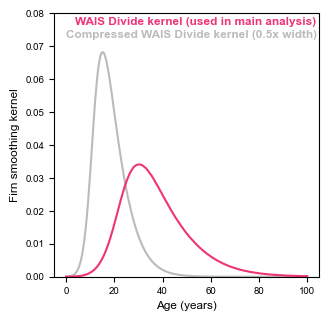

In [9]:
max_age = 100  # years
n_plot_old = int(max_age / firn_filter_old.dt) + 1
n_plot_new = int(max_age / firn_filter_new.dt) + 1
t_old = np.arange(0, n_plot_old * firn_filter_old.dt, firn_filter_old.dt)
t_new = np.arange(0, n_plot_new * firn_filter_new.dt, firn_filter_new.dt)
# t_old = np.arange(0, max_age + firn_filter_old.dt, firn_filter_old.dt)
# t_new = np.arange(0, max_age + firn_filter_new.dt, firn_filter_new.dt)

fig, ax = plt.subplots(
    figsize=(fig_width_options["one_column"], fig_width_options["one_column"])
)
ax.plot(
    t_new, firn_filter_new.kernel[:n_plot_new], label="new", color=color_smoothed_new
)
ax.plot(
    t_old,
    firn_filter_old.kernel[:n_plot_old],
    label="original",
    color=color_smoothed_orig,
)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Firn smoothing kernel")
ax.set_ylim(0, 0.08)

legend_x = 0.99
legend_y_start = 0.95
legend_dy = 0.05
ax.text(
    legend_x,
    legend_y_start,
    "WAIS Divide kernel (used in main analysis)",
    color=color_smoothed_orig,
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax.transAxes,
)
ax.text(
    legend_x,
    legend_y_start - legend_dy,
    "Compressed WAIS Divide kernel (0.5x width)",
    color=color_smoothed_new,
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax.transAxes,
)

# save figure in pdf format
name = "firn_filter"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/supplement/{name}.pdf",
    bbox_inches="tight",
    dpi=200,
)

In [10]:
## functions
def calc_bins(ylim):
    bin_min = int(np.floor(ylim[0] / 5) * 5)  # round down to nearest 5
    bin_max = int(np.ceil(ylim[1] / 5) * 5)  # round up to nearest 5
    n_bins = int((bin_max - bin_min) / 5)  # tune as needed
    return bin_min, bin_max, n_bins


def normalized_histogram(data_plot, bin_min, bin_max, n_bins):
    """Compute a normalized histogram and bin centers."""
    bins = np.linspace(bin_min, bin_max, n_bins + 1)
    hist, bin_edges = np.histogram(data_plot, bins=bins)
    hist_frac = hist / hist.sum()
    return hist_frac, bin_edges


def slice_data_in_time(
    ds_instantaneous, ds_smoothed, ds_sampled, time_min, time_max, instantaneous_offset
):
    """
    Slice data to align to the same time

    datasets should be pre-sliced to the timescale and the ensemble member
    """
    time_slice = slice(time_min, time_max)
    time_slice_instantaneous = slice(
        time_min - instantaneous_offset, time_max - instantaneous_offset
    )
    instantaneous_plot = ds_instantaneous["ch4"].sel(time=time_slice_instantaneous)
    smoothed_plot = ds_smoothed["ch4"].sel(time=time_slice)
    sampled_plot = ds_sampled["ch4"].sel(time=time_slice)
    return instantaneous_plot, smoothed_plot, sampled_plot


def plot_noise_timeseries(
    ax_ts, instantaneous_plot, smoothed_plot, sampled_plot, instantaneous_offset, ylim
):
    ax_ts.axhline(0, color="k", linestyle="-.", alpha=0.3)
    ax_ts.plot(
        instantaneous_plot.time + instantaneous_offset,
        instantaneous_plot,
        **plot_kwargs["instantaneous"],
    )
    ax_ts.plot(smoothed_plot.time, smoothed_plot, **plot_kwargs["smoothed"])
    ax_ts.plot(sampled_plot.time, sampled_plot, **plot_kwargs["sampled"])
    ax_ts.set_ylim(ylim)


def plot_noise_histogram(
    ax_kd, hist_instantaneous, hist_sampled, bin_edges, plot_kwargs, ylim, xlim=[]
):
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax_kd.barh(
        bin_centers,
        hist_instantaneous,
        height=(bin_edges[1] - bin_edges[0]),
        color=plot_kwargs["instantaneous"]["color"],
        alpha=0.45,
        edgecolor="k",
        linewidth=0.2,
    )
    ax_kd.barh(
        bin_centers,
        hist_sampled,
        height=(bin_edges[1] - bin_edges[0]),
        color=plot_kwargs["sampled"]["color"],
        alpha=0.5,
        edgecolor="k",
        linewidth=0.2,
    )
    ax_kd.axhline(0, color="k", linestyle="-.", alpha=0.3)

    ax_kd.set_ylim(ylim)
    ax_kd.set_xlim(xlim)
    ax_kd.set_ylabel("")


def format_xticks(ax, direction="in", length_major=4, length_minor=2, show_label=False):
    if not show_label:
        ax.set_xticklabels([])  # 1. no labels
    ax.tick_params(
        axis="x", which="major", direction=direction, length=length_major
    )  # 2. major ticks inside
    ax.xaxis.set_minor_locator(
        plt.MultipleLocator((ax.get_xticks()[1] - ax.get_xticks()[0]) / 2)
    )  # 3. minor ticks halfway
    ax.tick_params(
        axis="x", which="minor", direction=direction, length=length_minor
    )  # minor ticks inside, shorter


def format_yticks(ax, direction="in", length_major=3, length_minor=1, show_label=False):
    if not show_label:
        ax.set_yticklabels([])  # 1. no labels
    ax.tick_params(
        axis="y", which="major", direction=direction, length=length_major
    )  # 2. major ticks inside
    ax.yaxis.set_minor_locator(
        plt.MultipleLocator((ax.get_yticks()[1] - ax.get_yticks()[0]) / 2)
    )  # 3. minor ticks halfway
    ax.tick_params(
        axis="y", which="minor", direction=direction, length=length_minor
    )  # minor ticks inside, shorter


# panel letter annotations
_letters = list(string.ascii_lowercase)


def panel_letter(idx: int) -> str:
    """0->'a', 1->'b', ..."""
    return _letters[idx]


def annotate_panel(ax, text, loc="left", pad=0.01, fontsize=large_font):
    """Place bold, black text at the top-left/right inside an axis."""
    x = pad if loc == "left" else 1 - pad
    ha = "left" if loc == "left" else "right"
    ax.text(
        x,
        0.98,
        text,
        transform=ax.transAxes,
        ha=ha,
        va="top",
        fontsize=fontsize,
        fontweight="bold",
        color="k",
    )


def year_label(timescale: float) -> str:
    """Singular/plural label."""
    return "year" if abs(timescale - 1) < 1e-12 else "years"


def timescale_label(letter: str, tau: float) -> str:
    """
    Build '(c) \\boldsymbol{\\tau}_{\\varepsilon} = 10 years'
    (entire string will be bold via annotate_panel; math part bolded via \\boldsymbol)
    """
    return (
        f"({letter}) "
        + r"$\boldsymbol{\tau}_{\varepsilon}$"
        + f" = {tau:g} {year_label(tau)}"
    )


# std annotations
def _sigma_text(val: float) -> str:
    return f"\u03c3\u00a0=\u00a0{val:.1f}"


def annotate_sigma_single(ax, value, color="k", x=0.98, y=0.02, fontsize=large_font):
    ax.text(
        x,
        y,
        _sigma_text(value),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        color=color,
    )


def annotate_sigma_double(
    ax,
    top_value,
    bottom_value,
    top_color="k",
    bottom_color="k",
    x=0.98,
    y=0.03,
    dy=0.1,
    fontsize=large_font,
):
    # bottom line
    ax.text(
        x,
        y,
        _sigma_text(bottom_value),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        color=bottom_color,
    )
    # top line (stacked above)
    ax.text(
        x,
        y + dy,
        _sigma_text(top_value),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        color=top_color,
    )

Text(0.99, 0.65, 'Firn-smoothed (original)')

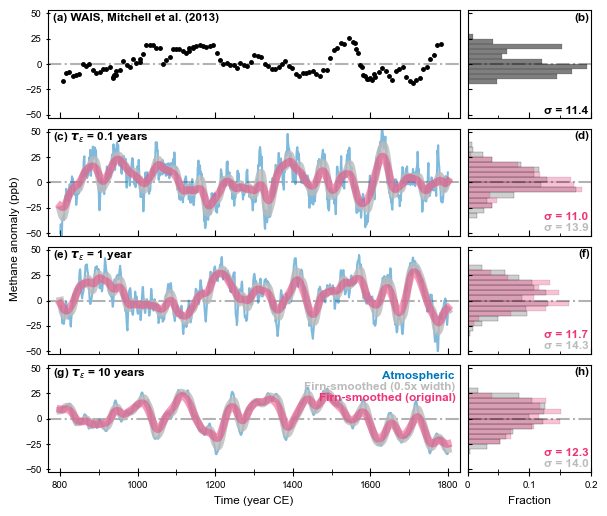

In [11]:
## grand plot
# parameters
time_min = 800
time_max = 1800
instantaneous_offset = 165
plot_oh_forced_methane = (
    False  # flag for plotting OH-forced timeseries, negative if inverted
)
oh_scaling = -6.5  # scaling factor for OH-forced timeseries
time_min_oh = 3280
time_max_oh = 4280
timescales_to_plot = [0.1, 1, 10]
ylim = (-53, 53)
yticks = [-50, -25, 0, 25, 50]
xlim_kd = (0, 0.2)
xticks_kd = [0, 0.1, 0.2]
xlim_ts = (time_min - 30, time_max + 30)
xticks_ts = [800, 1000, 1200, 1400, 1600, 1800]
idx_ens_noise = {
    0.1: 22,  # 3, 4, 22, 29
    1: 26,  # 2, 7, 22, 26
    10: 14,  # 1, 3, 14,
    100: 7,
    1000: 7,
}

if plot_oh_forced_methane:
    num_rows = 1 + len(timescales_to_plot) + 1
else:
    num_rows = 1 + len(timescales_to_plot)
fig = plt.figure(figsize=(fig_width, num_rows * ax_height))
gs = GridSpec(
    nrows=num_rows,
    ncols=2,
    figure=fig,
    width_ratios=[1, 0.3],
    wspace=0.03,
    hspace=0.1,
)
ax_ts = [None] * num_rows
ax_kd = [None] * num_rows

## --- Observations ---
## obs timeseries
ax_ts[0] = fig.add_subplot(gs[0, 0])  # timeseries
ax_kd[0] = fig.add_subplot(gs[0, 1])  # kernel density
time_slice = slice(time_min, time_max)
data_plot = data_obs["ch4_detrended"].sel(time=time_slice)

ax_ts[0].plot(data_plot.time, data_plot, **plot_kwargs["obs"])
ax_ts[0].axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_ts[0].set_xlim(xlim_ts)
ax_ts[0].set_ylim(ylim)
ax_ts[0].set_yticks(yticks)
format_xticks(ax_ts[0])
format_yticks(ax_ts[0], direction="inout", show_label=True, length_minor=0)

## obs histogram
bin_min, bin_max, n_bins = calc_bins(ylim)
hist_frac, bin_edges = normalized_histogram(data_plot, bin_min, bin_max, n_bins)

# bin centers for plotting
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
ax_kd[0].barh(
    bin_centers,
    hist_frac,
    height=(bin_edges[1] - bin_edges[0]),
    color="k",
    alpha=0.5,
    edgecolor="k",
    linewidth=0.2,
)
ax_kd[0].axhline(0, color="k", linestyle="-.", alpha=0.3)

ax_kd[0].set_xlim(xlim_kd)
ax_kd[0].set_xticks(xticks_kd)
format_xticks(ax_kd[0])
ax_kd[0].set_ylim(ylim)
ax_kd[0].set_yticks(yticks)
ax_kd[0].set_ylabel("")
format_yticks(ax_kd[0], length_minor=0)

# annotation for standard deviation
sigma_obs = float(np.nanstd(np.asarray(data_plot), ddof=1))
annotate_sigma_single(ax_kd[0], sigma_obs, color=plot_kwargs["obs"]["color"])

## --- Timescales ---
for i, timescale in enumerate(timescales_to_plot):
    ax_ts[1 + i] = fig.add_subplot(gs[1 + i, 0])  # timeseries
    ax_kd[1 + i] = fig.add_subplot(gs[1 + i, 1])  # kernel density

    # timeseries
    instantaneous_plot, smoothed_plot_new, sampled_plot_new = slice_data_in_time(
        ds_instantaneous=instantaneous_noise[timescale].isel(
            ensemble=idx_ens_noise[timescale]
        ),
        ds_smoothed=smoothed_noise_new[timescale].isel(
            ensemble=idx_ens_noise[timescale]
        ),
        ds_sampled=sampled_noise_new[timescale].isel(ensemble=idx_ens_noise[timescale]),
        time_min=time_min,
        time_max=time_max,
        instantaneous_offset=instantaneous_offset,
    )
    instantaneous_plot, smoothed_plot, sampled_plot = slice_data_in_time(
        ds_instantaneous=instantaneous_noise[timescale].isel(
            ensemble=idx_ens_noise[timescale]
        ),
        ds_smoothed=smoothed_noise[timescale].isel(ensemble=idx_ens_noise[timescale]),
        ds_sampled=sampled_noise[timescale].isel(ensemble=idx_ens_noise[timescale]),
        time_min=time_min,
        time_max=time_max,
        instantaneous_offset=instantaneous_offset,
    )
    ax_ts[1 + i].axhline(0, color="k", linestyle="-.", alpha=0.3)
    ax_ts[1 + i].plot(
        instantaneous_plot.time + instantaneous_offset,
        instantaneous_plot,
        **plot_kwargs["instantaneous"],
    )
    ax_ts[1 + i].plot(  # new smoothed (less smoothing)
        smoothed_plot_new.time, smoothed_plot_new, **plot_kwargs["smoothed"]
    )
    ax_ts[1 + i].plot(  # old smoothed
        smoothed_plot.time,
        smoothed_plot,
        color=color_smoothed_orig,
        linestyle="-",
        linewidth=5.5,
        alpha=0.48,
    )
    ax_ts[1 + i].set_ylim(ylim)
    ax_ts[1 + i].set_yticks(yticks)
    ax_ts[1 + i].set_xlim(xlim_ts)
    format_xticks(ax_ts[1 + i])
    format_yticks(ax_ts[1 + i], direction="inout", show_label=True, length_minor=0)

    # histograms
    bin_min, bin_max, n_bins = calc_bins(ylim)
    hist_smoothed, bin_edges = normalized_histogram(
        smoothed_plot, bin_min, bin_max, n_bins
    )
    hist_smoothed_new, _ = normalized_histogram(
        smoothed_plot_new, bin_min, bin_max, n_bins
    )
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax_kd[1 + i].barh(
        bin_centers,
        hist_smoothed_new,
        height=(bin_edges[1] - bin_edges[0]),
        color=plot_kwargs["smoothed"]["color"],
        alpha=0.7,
        edgecolor="k",
        linewidth=0.2,
    )
    ax_kd[1 + i].barh(
        bin_centers,
        hist_smoothed,
        height=(bin_edges[1] - bin_edges[0]),
        color=color_smoothed_orig,
        alpha=0.3,
        edgecolor="k",
        linewidth=0.2,
    )
    ax_kd[1 + i].axhline(0, color="k", linestyle="-.", alpha=0.3)

    ax_kd[1 + i].set_ylim(ylim)
    ax_kd[1 + i].set_xlim(xlim_kd)
    ax_kd[1 + i].set_ylabel("")

    ax_kd[1 + i].set_xticks(xticks_kd)
    ax_kd[1 + i].set_yticks(yticks)
    format_xticks(ax_kd[1 + i])
    format_yticks(ax_kd[1 + i], length_minor=0)

    # add annotations
    sigma_inst = float(np.nanstd(np.asarray(smoothed_plot), ddof=1))
    sigma_samp = float(np.nanstd(np.asarray(smoothed_plot_new), ddof=1))
    annotate_sigma_double(
        ax_kd[1 + i],
        top_value=sigma_inst,
        bottom_value=sigma_samp,
        top_color=color_smoothed_orig,
        bottom_color=color_smoothed_new,
    )

## --- labels and formatting ---
# add x label and tick labels to last row axes
format_xticks(ax_ts[-1], direction="inout", length_major=6, length_minor=4)
ax_ts[-1].set_xticks(xticks_ts)
ax_ts[-1].set_xticklabels(xticks_ts)
ax_ts[-1].set_xlabel("Time (year CE)")

format_xticks(ax_kd[-1], direction="inout", length_major=6, length_minor=4)
ax_kd[-1].set_xticks(xticks_kd)
ax_kd[-1].set_xticklabels(xticks_kd)
ax_kd[-1].set_xlabel("Fraction")

# add global y axis
fig.text(0.07, 0.5, "Methane anomaly (ppb)", va="center", rotation="vertical")

## --- annotations ---
# --- Top row (observations) ---
annotate_panel(
    ax_ts[0], f"({panel_letter(0)}) WAIS, Mitchell et al. (2013)", loc="left"
)
annotate_panel(ax_kd[0], f"({panel_letter(1)})", loc="right")
# --- Remaining rows (timescales) ---
for i, timescale in enumerate(timescales_to_plot):
    row = 1 + i
    # two letters per row: TS gets even index, KD gets the following odd index
    letter_ts = panel_letter(2 * row)
    letter_kd = panel_letter(2 * row + 1)

    # place "(c) τ_ε = X year(s)" on the timeseries axis, left-aligned
    annotate_panel(ax_ts[row], timescale_label(letter_ts, timescale), loc="left")

    # place "(d)" on the kernel-density axis, right-aligned
    annotate_panel(ax_kd[row], f"({letter_kd})", loc="right")
if plot_oh_forced_methane:
    # last row: OH-forced methane
    row = -1
    letter_ts = panel_letter(2 * (num_rows - 1))
    letter_kd = panel_letter(2 * (num_rows - 1) + 1)

    # place "(e) OH-forced methane" on the timeseries axis, left-aligned
    annotate_panel(
        ax_ts[row],
        f"({letter_ts})" + r" GFDL-CM3 OH$\times$" + f"{abs(oh_scaling)}",
        loc="left",
    )

    # place "(f)" on the kernel-density axis, right-aligned
    annotate_panel(ax_kd[row], f"({letter_kd})", loc="right")
# legend (bottom right corner of last row)
legend_x = 0.99
legend_y_start = 0.65
legend_dy = 0.1
ax_ts[-1].text(
    legend_x - 0.003,
    legend_y_start + 2 * legend_dy,
    "Atmospheric",
    color=plot_kwargs["instantaneous"]["color"],
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax_ts[-1].transAxes,
)
ax_ts[-1].text(
    legend_x,
    legend_y_start + legend_dy,
    "Firn-smoothed (0.5x width)",
    color=plot_kwargs["smoothed"]["color"],
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax_ts[-1].transAxes,
)
ax_ts[-1].text(
    legend_x,
    legend_y_start,
    "Firn-smoothed (original)",
    color=color_smoothed_orig,
    fontweight="bold",
    ha="right",
    va="bottom",
    transform=ax_ts[-1].transAxes,
)

# # save figure in pdf format
# name = "fig_2"
# fig.savefig(
#     f"{cfg.paths.figures_dir}/for_publication/{name}.pdf", bbox_inches="tight", dpi=300
# )
# fig.savefig(
#     f"{cfg.paths.figures_dir}/for_publication/{name}.png", bbox_inches="tight", dpi=300
# )_